In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


In [ ]:
dataset_train = pd.read_csv('Google_Stock_Price_Train.csv')
training_set = dataset_train.iloc[: , 1:2].values

In [ ]:
dataset_train

,Date,Open,High,Low,Close,Volume
0,01/03/12,325.25,332.83,324.97,663.59,"73,80,500"
1,01/04/12,331.27,333.87,329.08,666.45,"57,49,400"
2,01/05/12,329.83,330.75,326.89,657.21,"65,90,300"
3,01/06/12,328.34,328.77,323.68,648.24,"54,05,900"
4,01/09/12,322.04,322.29,309.46,620.76,"1,16,88,800"
...,...,...,...,...,...,...
1253,12/23/2016,790.90,792.74,787.28,789.91,"6,23,400"
1254,12/27/2016,790.68,797.86,787.66,791.55,"7,89,100"
1255,12/28/2016,793.70,794.23,783.20,785.05,"11,53,800"
1256,12/29/2016,783.33,785.93,778.92,782.79,"7,44,300"


In [ ]:
dataset_train.shape

(1258, 6)

In [ ]:
training_set

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]])

In [ ]:
training_set.shape

(1258, 1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0,1))
training_set_scaled = sc.fit_transform(training_set)
training_set_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]])

In [ ]:
X_train = []
y_train = []
for i in range(60 , 1258):
  X_train.append(training_set_scaled[i-60: i,0])
  y_train.append(training_set_scaled[i,0])
X_train , y_train = np.array(X_train) , np.array(y_train)

In [ ]:
X_train.shape

(1198, 60)

In [ ]:
y_train.shape

(1198,)

In [ ]:
X_train = np.reshape(X_train , (X_train.shape[0] , X_train.shape[1] , 1))

In [ ]:
from keras.models import Sequential
from keras.layers import Dense , LSTM ,Dropout

In [ ]:
regressor = Sequential()

In [ ]:
regressor.add(LSTM(units =50 , return_sequences= True , input_shape = (X_train.shape[1] , 1)))
regressor.add(Dropout(0.2))

In [ ]:
regressor.add(LSTM(units = 50 , return_sequences = True))
regressor.add(Dropout(0.2))

In [ ]:
regressor.add(LSTM( units =50 , return_sequences= True))
regressor.add(Dropout(0.2))

In [ ]:
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

In [ ]:
regressor.add(Dense(units =1))

In [ ]:
regressor.compile( optimizer = 'adam' , loss = 'mean_squared_error')

In [ ]:
regressor.fit(X_train , y_train , epochs = 100 , batch_size = 32)

Epoch 1/100
38/38 [==============================] - 5s 127ms/step - loss: 0.0033
Epoch 2/100
38/38 [==============================] - 5s 122ms/step - loss: 0.0033
Epoch 3/100
38/38 [==============================] - 5s 122ms/step - loss: 0.0030
Epoch 4/100
38/38 [==============================] - 5s 122ms/step - loss: 0.0034
Epoch 5/100
38/38 [==============================] - 5s 125ms/step - loss: 0.0031
Epoch 6/100
38/38 [==============================] - 5s 120ms/step - loss: 0.0028
Epoch 7/100
38/38 [==============================] - 5s 124ms/step - loss: 0.0032
Epoch 8/100
38/38 [==============================] - 5s 120ms/step - loss: 0.0031
Epoch 9/100
38/38 [==============================] - 5s 121ms/step - loss: 0.0035
Epoch 10/100
38/38 [==============================] - 5s 122ms/step - loss: 0.0028
Epoch 11/100
38/38 [==============================] - 5s 124ms/step - loss: 0.0028
Epoch 12/100
38/38 [==============================] - 5s 122ms/step - loss: 0.0027
Epoch 13/100


In [ ]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')
real_stock_price = dataset_test.iloc[: , 1:2].values

In [ ]:
real_stock_price.shape

(20, 1)

In [ ]:
dataset_total = pd.concat((dataset_train['Open'] , dataset_test['Open']) , axis =0)
inputs = dataset_total[ len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)

In [ ]:
inputs = sc.transform(inputs)

In [ ]:
X_test = []
for i in range(60,80):
  X_test.append(inputs [i-60:i , 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test , (X_test.shape[0], X_test.shape[1] , 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

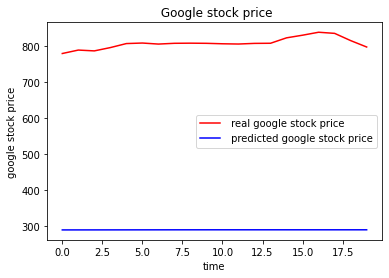

In [ ]:
plt.plot(real_stock_price , color = 'red' , label = ' real google stock price')
plt.plot(predicted_stock_price , color = 'blue', label = ' predicted google stock price')
plt.title(' Google stock price')
plt.xlabel('time')
plt.ylabel('google stock price')
plt.legend()
plt.show()